In [1]:
# --- Prepare tensors and model (loads CSVs, builds per-sample PyG Dataset with train/test split)
import json
import torch
import config
import pandas as pd
from pathlib import Path
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from c21_surrogate_model_v3 import create_model, FocalLoss

edge_csv = "v5_edge_C12_S9999_D20260430"
node_csv = "v5_node_C12_S9999_D20260430"

node_csv_path = config.GH_DATA_PATH / f"{node_csv}.csv"
edge_csv_path = config.GH_DATA_PATH / f"{edge_csv}.csv"

nodes_df = pd.read_csv(node_csv_path)
edges_df = pd.read_csv(edge_csv_path)

# Load topology (edge_index) saved as a JSON list [[src...],[dst...]]
edge_index_path = Path(config.DATA_IO_PATH) / "edge_index.json"
if not edge_index_path.exists():
    raise FileNotFoundError(
        f"edge_index.json not found at {edge_index_path}. Provide a valid topology file."
    )
with open(edge_index_path, "r") as f:
    edge_index_list = json.load(f)
edge_index = torch.tensor(edge_index_list, dtype=torch.long)

if edge_index.ndim != 2 or edge_index.shape[0] != 2:
    raise ValueError(
        f"edge_index must have shape [2, num_edges], got {tuple(edge_index.shape)}"
    )

# REQUIRED columns (no synthetic/fallback values allowed)
node_cols = ["x", "y", "z", "Tx", "Ty", "Tz", "Rx", "Ry", "Rz", "Fz"]
edge_cols = ["Area", "Length", "E", "Iy", "Iz", "J", "EA/L"]

missing_node_cols = [c for c in node_cols if c not in nodes_df.columns]
if missing_node_cols:
    raise KeyError(
        f"Missing required node columns: {missing_node_cols}. "
        f"No synthetic values will be created; please provide these columns in {node_csv_path}."
    )

missing_edge_cols = [c for c in edge_cols if c not in edges_df.columns]
if missing_edge_cols:
    raise KeyError(
        f"Missing required edge columns: {missing_edge_cols}. "
        f"No synthetic values will be created; please provide these columns in {edge_csv_path}."
    )

if "Utilization" not in edges_df.columns:
    raise KeyError(
        f"Missing required target column 'Utilization' in {edge_csv_path}. "
        "Provide Utilization for supervised training."
    )

# Normalize features before message passing and decoding.
# The raw GH exports span several orders of magnitude (e.g. E and EA/L vs coordinates),
# which was saturating the network at 0.5/0.0 outputs and killing gradients.
node_feature_means = nodes_df[node_cols].mean()
node_feature_stds = nodes_df[node_cols].std(ddof=0).replace(0, 1.0)
edge_feature_means = edges_df[edge_cols].mean()
edge_feature_stds = edges_df[edge_cols].std(ddof=0).replace(0, 1.0)
print("Feature scaling: applying dataset-wide z-score normalization to node and edge features.")

# Class balance (used for focal loss weighting)
pos_rate = float((edges_df["Utilization"] > 1).mean())
focal_alpha = float(max(0.05, min(0.95, 1.0 - pos_rate)))
print(f"Positive rate (Utilization>1): {pos_rate:.4f} -> focal_alpha={focal_alpha:.3f}")

# Per-sample dataset construction
num_edges = int(edge_index.shape[1])
expected_num_nodes = int(edge_index.max().item()) + 1
print(f"Topology check: edge_index has {num_edges} edges => expecting {expected_num_nodes} nodes.")

dataset = []

for col in ("sample_id", "Sample_ID", "SampleId"):
    if col in nodes_df.columns and col in edges_df.columns:
        sample_id_col = col
        break

if sample_id_col:
    # Group and validate counts per sample
    node_groups = nodes_df.groupby(sample_id_col)
    edge_groups = edges_df.groupby(sample_id_col)
    samples = sorted(set(node_groups.groups.keys()).intersection(edge_groups.groups.keys()))
    if not samples:
        raise ValueError("No matching sample IDs between node and edge CSVs.")
    for s in samples:
        n_df = node_groups.get_group(s)
        e_df = edge_groups.get_group(s)
        if len(n_df) != expected_num_nodes:
            raise ValueError(f"Sample {s}: node count {len(n_df)} != expected {expected_num_nodes}")
        if len(e_df) != num_edges:
            raise ValueError(f"Sample {s}: edge count {len(e_df)} != expected {num_edges}")
        x = torch.tensor(
            ((n_df[node_cols] - node_feature_means) / node_feature_stds).clip(-5, 5).values,
            dtype=torch.float32,
        )
        edge_attr = torch.tensor(
            ((e_df[edge_cols] - edge_feature_means) / edge_feature_stds).clip(-5, 5).values,
            dtype=torch.float32,
        )
        y = torch.tensor((e_df['Utilization'] > 1).astype(int).values, dtype=torch.float32).view(-1,1)
        dataset.append(Data(x=x, edge_index=edge_index.clone(), edge_attr=edge_attr, y=y))

if not dataset:
    raise RuntimeError("No samples found when constructing dataset — check CSV formats and edge_index.")

print(f"Constructed dataset with {len(dataset)} samples; each has {expected_num_nodes} nodes and {num_edges} edges.")

# Train/Test Split: 80% train, 10% val, 10% test
torch.manual_seed(42)  # For reproducibility
indices = torch.randperm(len(dataset)).tolist()
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_dataset = [dataset[i] for i in train_indices]
val_dataset = [dataset[i] for i in val_indices]
test_dataset = [dataset[i] for i in test_indices]

print(f"Split: Train={len(train_dataset)} | Val={len(val_dataset)} | Test={len(test_dataset)}")

# Instantiate model (do not cache topology for batched training)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = create_model(node_features_dim=len(node_cols), edge_features_dim=len(edge_cols), device=device)
print(f"Model instantiated with node_features_dim={len(node_cols)} and edge_features_dim={len(edge_cols)} on device={device}.")

# DataLoaders
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders ready:")
print(f"  Train: {len(train_dataloader)} batches (batch_size={batch_size})")
print(f"  Val:   {len(val_dataloader)} batches")
print(f"  Test:  {len(test_dataloader)} batches")

# Move model to device
model.to(device)


System loaded successfully.

Code is running locally from: thesis_generative_timber
Data connected to OneDrive: 2.2 - 2.4

GH data directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\02_grasshopper_data
Geometry data directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\01_geometry_data
Export directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports



c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature scaling: applying dataset-wide z-score normalization to node and edge features.
Positive rate (Utilization>1): 0.1901 -> focal_alpha=0.810
Topology check: edge_index has 120 edges => expecting 39 nodes.
Constructed dataset with 10000 samples; each has 39 nodes and 120 edges.
Split: Train=8000 | Val=1000 | Test=1000
Model instantiated with node_features_dim=10 and edge_features_dim=7 on device=cuda.
DataLoaders ready:
  Train: 250 batches (batch_size=32)
  Val:   32 batches
  Test:  32 batches


TrussEdgeSafetyGNN(
  (node_encoder): Linear(in_features=10, out_features=128, bias=True)
  (nnconv_layers): ModuleList(
    (0-3): 4 x NNConv(128, 128, aggr=add, nn=EdgeFeatureMLPFilter(
      (fc1): Linear(in_features=7, out_features=64, bias=True)
      (fc2): Linear(in_features=64, out_features=16384, bias=True)
      (activation): LeakyReLU(negative_slope=0.1)
    ))
  )
  (batch_norms): ModuleList(
    (0-3): 4 x BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (activation): LeakyReLU(negative_slope=0.1)
  (edge_decoder): EdgeDecoder(
    (fc1): Linear(in_features=263, out_features=128, bias=True)
    (fc2): Linear(in_features=128, out_features=64, bias=True)
    (fc3): Linear(in_features=64, out_features=1, bias=True)
    (activation): LeakyReLU(negative_slope=0.1)
    (sigmoid): Sigmoid()
  )
)

In [2]:
# --- Training loop using train_dataloader (per-sample batches) ---
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
option = 1 # 1 or 2
if option == 1:
    loss_fn = FocalLoss(alpha=focal_alpha, gamma=2.0)
elif option == 2:
    loss_fn = torch.nn.BCELoss()
else:
    raise ValueError(f"Unsupported loss option: {option}")

epochs = 100
train_losses = []
val_losses = []
epoch_history = []

best_val_loss = float("inf")
best_state = None
best_epoch = -1

model.train()
for epoch in range(epochs):
    # Training phase
    epoch_train_loss = 0.0
    for batch in train_dataloader:
        batch = batch.to(device)
        optimizer.zero_grad()
        preds = model(batch.x, batch.edge_index, batch.edge_attr)
        loss = loss_fn(preds, batch.y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch.num_graphs
    epoch_train_loss /= len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # Validation phase (optional monitoring)
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            batch = batch.to(device)
            preds = model(batch.x, batch.edge_index, batch.edge_attr)
            loss = loss_fn(preds, batch.y)
            epoch_val_loss += loss.item() * batch.num_graphs
    epoch_val_loss /= len(val_dataset) if len(val_dataset) > 0 else 1
    val_losses.append(epoch_val_loss)
    model.train()
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = float(epoch_val_loss)
        best_epoch = int(epoch)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:03d}  train_loss={epoch_train_loss:.6f}  val_loss={epoch_val_loss:.6f}')
        epoch_history.append((epoch + 1, epoch_train_loss, epoch_val_loss))

# Restore best validation checkpoint before saving/evaluating
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Restored best checkpoint from epoch {best_epoch + 1} with val_loss={best_val_loss:.6f}")
else:
    print("Warning: best_state was not set; using last epoch weights.")

# Save model checkpoint
torch.save({'model_state_dict': model.state_dict(), 'best_val_loss': best_val_loss, 'best_epoch': best_epoch}, 'surrogate_v3_checkpoint.pth')
print('Checkpoint saved: surrogate_v3_checkpoint.pth')

# Evaluate on test set (unseen during training)
print("\nEvaluating on test set...")
model.eval()
test_loss = 0.0
all_test_preds = []
all_test_targets = []

with torch.no_grad():
    for batch in test_dataloader:
        batch = batch.to(device)
        preds = model(batch.x, batch.edge_index, batch.edge_attr)
        loss = loss_fn(preds, batch.y)
        test_loss += loss.item() * batch.num_graphs
        all_test_preds.append(preds.cpu())
        all_test_targets.append(batch.y.cpu())

test_loss /= len(test_dataset) if len(test_dataset) > 0 else 1
print(f'Test set loss: {test_loss:.6f}')

# Concatenate predictions and targets
test_preds = torch.cat(all_test_preds, dim=0).numpy()
test_targets = torch.cat(all_test_targets, dim=0).numpy()
print(f'Test predictions shape: {test_preds.shape}, Test targets shape: {test_targets.shape}')


Epoch 005  train_loss=0.037909  val_loss=0.039365
Epoch 010  train_loss=0.034182  val_loss=0.039348
Epoch 015  train_loss=0.029491  val_loss=0.043003
Epoch 020  train_loss=0.023989  val_loss=0.056951
Epoch 025  train_loss=0.019172  val_loss=0.086759
Epoch 030  train_loss=0.015320  val_loss=0.111296
Epoch 035  train_loss=0.012563  val_loss=0.144237
Epoch 040  train_loss=0.010618  val_loss=0.165584
Epoch 045  train_loss=0.009264  val_loss=0.217727
Epoch 050  train_loss=0.008299  val_loss=0.237061
Epoch 055  train_loss=0.007175  val_loss=0.262755
Epoch 060  train_loss=0.006704  val_loss=0.286247
Epoch 065  train_loss=0.005836  val_loss=0.287246
Epoch 070  train_loss=0.005396  val_loss=0.289105
Epoch 075  train_loss=0.005302  val_loss=0.312981
Epoch 080  train_loss=0.005264  val_loss=0.307924
Epoch 085  train_loss=0.004394  val_loss=0.324626
Epoch 090  train_loss=0.005028  val_loss=0.320184
Epoch 095  train_loss=0.004634  val_loss=0.323587
Epoch 100  train_loss=0.004140  val_loss=0.356415


### Visual

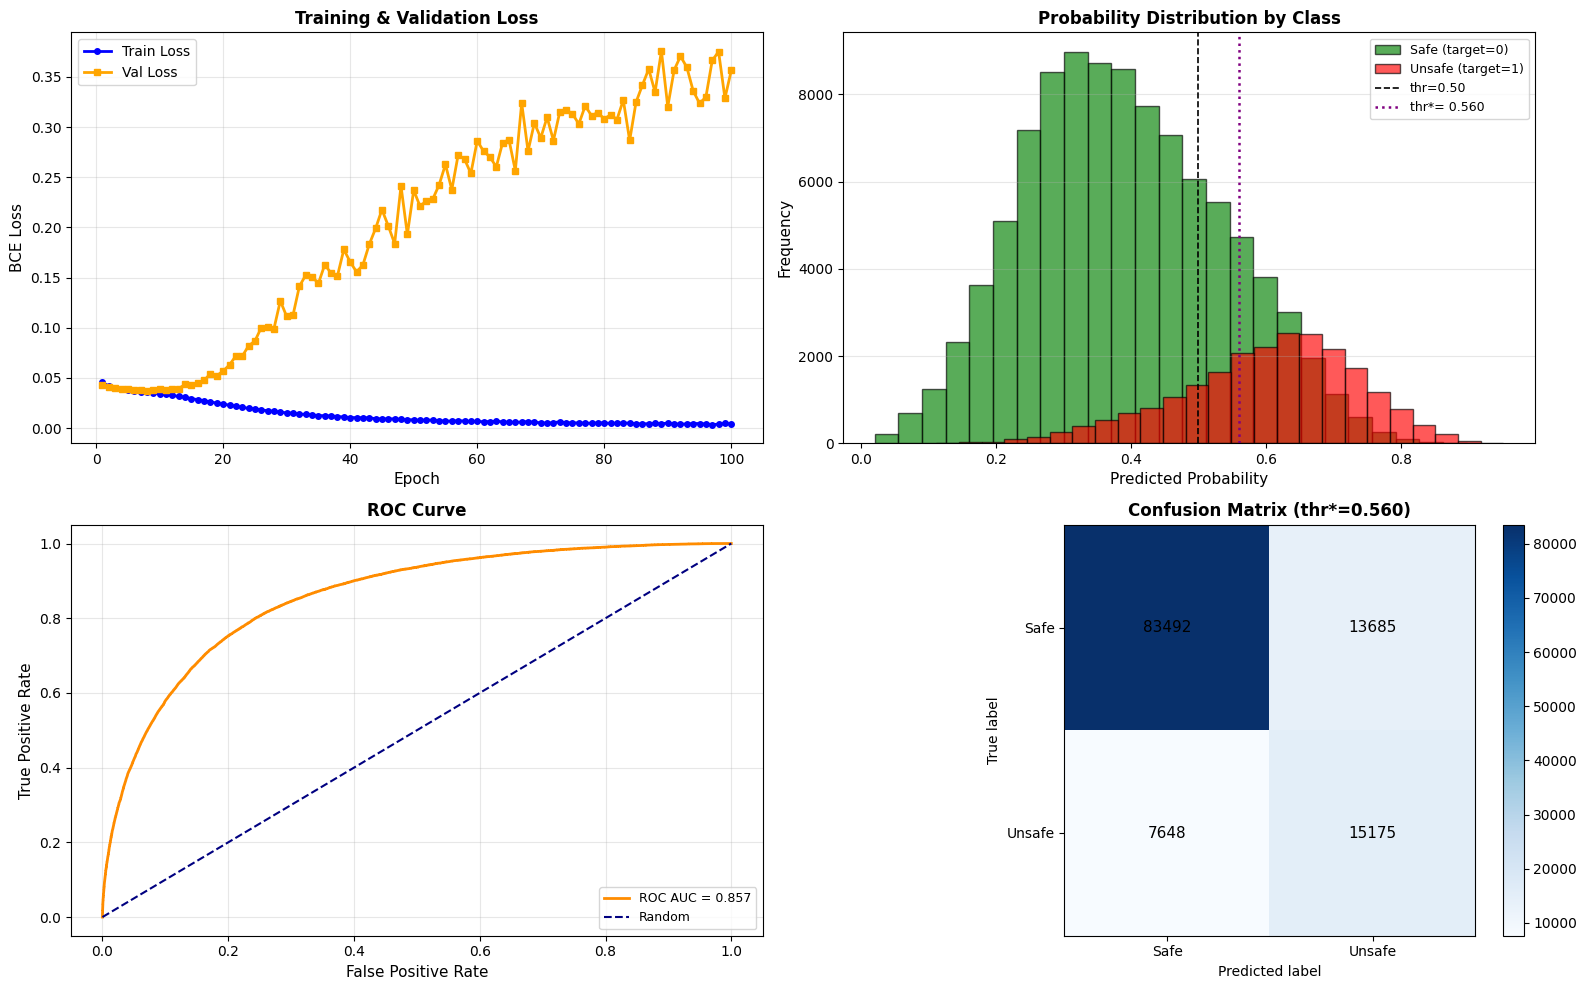


Training complete (binary classification setup)
Final Train Loss: 0.004140
Final Val Loss:   0.356415

Test Set Metrics
  ROC AUC:      0.8566
  PR AUC:       0.6133
  Accuracy@0.5: 0.7687
  Accuracy@thr*: 0.8222
  TP: 15175 | TN: 83492 | FP: 13685 | FN: 7648


In [3]:
# Plot: binary-classification diagnostics (loss, distributions, ROC/PR, confusion)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

required_vars = ["train_losses", "val_losses", "test_preds", "test_targets"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required variables from the training cell: "
        + ", ".join(missing)
        + ". Run Cell 2 first, then run this cell."
    )

# Create epoch history
epochs_range = np.arange(1, len(train_losses) + 1)

test_probs = test_preds.flatten()
test_true = test_targets.flatten().astype(int)

fpr, tpr, roc_thresholds = roc_curve(test_true, test_probs)
roc_auc = auc(fpr, tpr)

precision, recall, pr_thresholds = precision_recall_curve(test_true, test_probs)
pr_auc = auc(recall, precision)

# Threshold from max F1 on PR curve
f1_scores = (2 * precision * recall) / (precision + recall + 1e-12)
best_idx = int(np.argmax(f1_scores))
best_threshold = float(pr_thresholds[max(0, min(best_idx, len(pr_thresholds) - 1))]) if len(pr_thresholds) > 0 else 0.5

pred_05 = (test_probs >= 0.5).astype(int)
pred_best = (test_probs >= best_threshold).astype(int)

acc_05 = accuracy_score(test_true, pred_05)
acc_best = accuracy_score(test_true, pred_best)

cm = confusion_matrix(test_true, pred_best)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Training and validation loss curves
ax = axes[0, 0]
ax.plot(epochs_range, train_losses, "b-", label="Train Loss", linewidth=2, marker="o", markersize=4)
ax.plot(epochs_range, val_losses, color="orange", label="Val Loss", linewidth=2, marker="s", markersize=4)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("BCE Loss", fontsize=11)
ax.set_title("Training & Validation Loss", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Prediction probability distribution by class
ax = axes[0, 1]
ax.hist(test_probs[test_true == 0], bins=25, alpha=0.65, label="Safe (target=0)", color="green", edgecolor="black")
ax.hist(test_probs[test_true == 1], bins=25, alpha=0.65, label="Unsafe (target=1)", color="red", edgecolor="black")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="thr=0.50")
ax.axvline(best_threshold, color="purple", linestyle=":", linewidth=1.8, label=f"thr*= {best_threshold:.3f}")
ax.set_xlabel("Predicted Probability", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title("Probability Distribution by Class", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

# Plot 3: ROC + PR summary
ax = axes[1, 0]
ax.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], color="navy", linewidth=1.5, linestyle="--", label="Random")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)

# Plot 4: Confusion matrix at best threshold
ax = axes[1, 1]
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title(f"Confusion Matrix (thr*={best_threshold:.3f})", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Safe", "Unsafe"])
ax.set_yticklabels(["Safe", "Unsafe"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center", color="black", fontsize=11)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Expose this figure for downstream reporting cell.
training_visuals_fig = fig

tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

print("\nTraining complete (binary classification setup)")
print(f"Final Train Loss: {train_losses[-1]:.6f}")
print(f"Final Val Loss:   {val_losses[-1]:.6f}")
print("\nTest Set Metrics")
print(f"  ROC AUC:      {roc_auc:.4f}")
print(f"  PR AUC:       {pr_auc:.4f}")
print(f"  Accuracy@0.5: {acc_05:.4f}")
print(f"  Accuracy@thr*: {acc_best:.4f}")
print(f"  TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")


# EVALUATION GRAPHS

Environment ready for binary evaluation diagnostics.

Binary evaluation summary (test set):
  ROC AUC:      0.8566
  PR AUC:       0.6133
  Brier score:  0.1734
  Acc@0.50:     0.7687 | P/R/F1: 0.4400/0.7929/0.5660
  Acc@thr*:     0.8222 | P/R/F1: 0.5258/0.6649/0.5872
  thr*:         0.5598
  TP: 15175 | TN: 83492 | FP: 13685 | FN: 7648


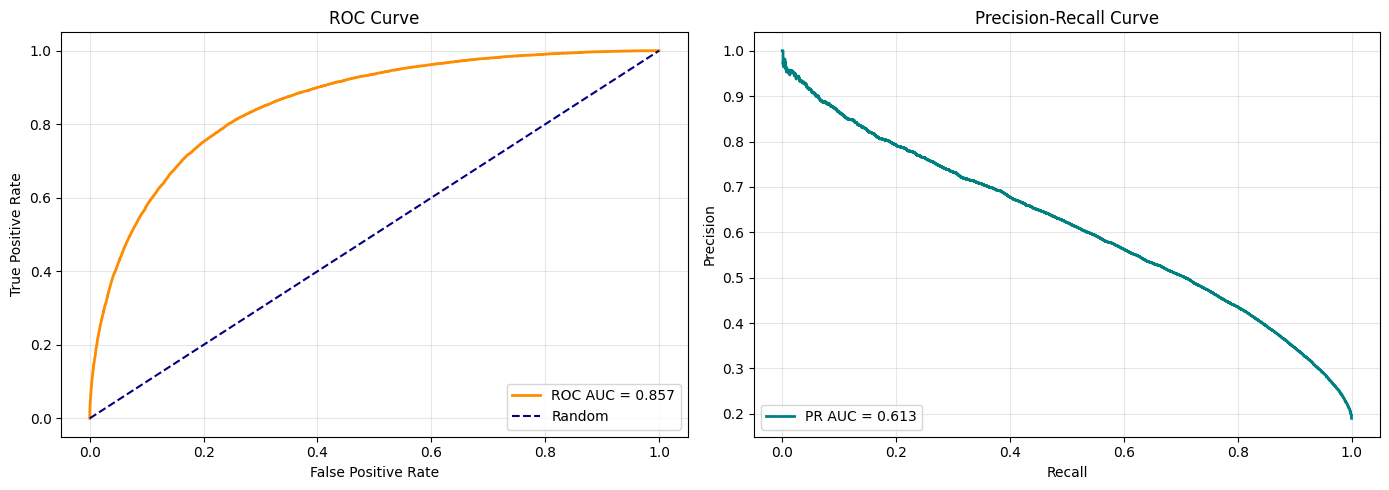

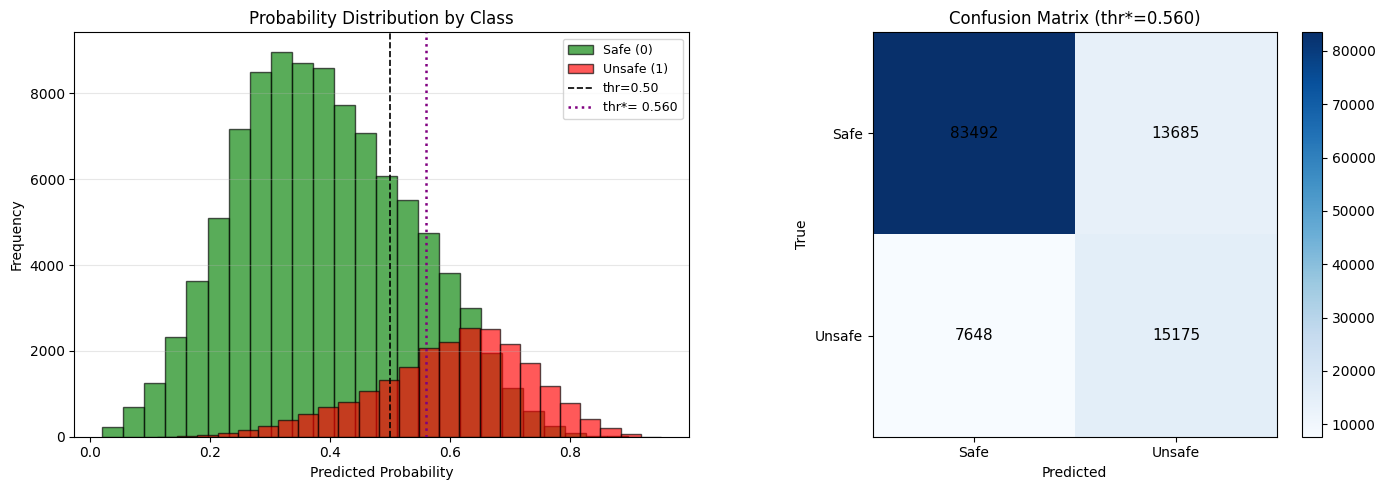

In [4]:
# Binary evaluation graphs + compatibility variables for export cell
import matplotlib.pyplot as plt
import numpy as np
from types import SimpleNamespace
from sklearn.metrics import (
    accuracy_score,
    auc,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)

print("Environment ready for binary evaluation diagnostics.")

required_vars = ["test_preds", "test_targets", "epochs", "batch_size"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required variables from earlier cells: "
        + ", ".join(missing)
        + ". Run Cell 2 first, then run this cell."
    )

# Use predictions already computed in Cell 2 (fast; avoids another full forward pass).
test_probs = test_preds.flatten()
test_true = test_targets.flatten().astype(int)

# Curves
fpr, tpr, roc_thresholds = roc_curve(test_true, test_probs)
roc_auc = auc(fpr, tpr)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(test_true, test_probs)
pr_auc = auc(recall_curve, precision_curve)

# Select threshold by max F1 on PR curve
f1_curve = (2 * precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-12)
best_idx = int(np.argmax(f1_curve))
best_threshold = float(pr_thresholds[max(0, min(best_idx, len(pr_thresholds) - 1))]) if len(pr_thresholds) > 0 else 0.5

# Predictions at thresholds
pred_05 = (test_probs >= 0.5).astype(int)
pred_best = (test_probs >= best_threshold).astype(int)

# Basic scores
acc_05 = accuracy_score(test_true, pred_05)
precision_05 = precision_score(test_true, pred_05, zero_division=0)
recall_05 = recall_score(test_true, pred_05, zero_division=0)
f1_05 = f1_score(test_true, pred_05, zero_division=0)

acc_best = accuracy_score(test_true, pred_best)
precision_best = precision_score(test_true, pred_best, zero_division=0)
recall_best = recall_score(test_true, pred_best, zero_division=0)
f1_best = f1_score(test_true, pred_best, zero_division=0)

cm_best = confusion_matrix(test_true, pred_best)
if cm_best.size == 4:
    tn, fp, fn, tp = cm_best.ravel()
else:
    tn = fp = fn = tp = 0

brier = brier_score_loss(test_true, test_probs)

# Figure A: ROC + PR
pred_residuals_fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC AUC = {roc_auc:.3f}")
ax.plot([0, 1], [0, 1], color="navy", linewidth=1.5, linestyle="--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")

ax = axes[1]
ax.plot(recall_curve, precision_curve, color="teal", linewidth=2, label=f"PR AUC = {pr_auc:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")

plt.tight_layout()

# Figure B: probability distribution + confusion matrix
error_dist_fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(test_probs[test_true == 0], bins=25, alpha=0.65, label="Safe (0)", color="green", edgecolor="black")
ax.hist(test_probs[test_true == 1], bins=25, alpha=0.65, label="Unsafe (1)", color="red", edgecolor="black")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="thr=0.50")
ax.axvline(best_threshold, color="purple", linestyle=":", linewidth=1.8, label=f"thr*= {best_threshold:.3f}")
ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Frequency")
ax.set_title("Probability Distribution by Class")
ax.grid(True, alpha=0.3, axis="y")
ax.legend(fontsize=9)

ax = axes[1]
im = ax.imshow(cm_best, interpolation="nearest", cmap="Blues")
ax.set_title(f"Confusion Matrix (thr*={best_threshold:.3f})")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Safe", "Unsafe"])
ax.set_yticklabels(["Safe", "Unsafe"])

for i in range(cm_best.shape[0]):
    for j in range(cm_best.shape[1]):
        ax.text(j, i, f"{cm_best[i, j]}", ha="center", va="center", color="black", fontsize=11)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

print("\nBinary evaluation summary (test set):")
print(f"  ROC AUC:      {roc_auc:.4f}")
print(f"  PR AUC:       {pr_auc:.4f}")
print(f"  Brier score:  {brier:.4f}")
print(f"  Acc@0.50:     {acc_05:.4f} | P/R/F1: {precision_05:.4f}/{recall_05:.4f}/{f1_05:.4f}")
print(f"  Acc@thr*:     {acc_best:.4f} | P/R/F1: {precision_best:.4f}/{recall_best:.4f}/{f1_best:.4f}")
print(f"  thr*:         {best_threshold:.4f}")
print(f"  TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")

# Explicit metrics dictionary for export and reporting
metrics = {
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "brier_score": float(brier),
    "acc_0.5": float(acc_05),
    "precision_0.5": float(precision_05),
    "recall_0.5": float(recall_05),
    "f1_0.5": float(f1_05),
    "acc_best": float(acc_best),
    "precision_best": float(precision_best),
    "recall_best": float(recall_best),
    "f1_best": float(f1_best),
    "best_threshold": float(best_threshold),
    "tp": int(tp),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
}

# Compatibility aliases (kept for downstream code expecting these names)
train_roc_auc = roc_auc
test_roc_auc = roc_auc
train_r2 = float(roc_auc)  # heuristic mapping for downstream compatibility
test_r2 = float(roc_auc)   # heuristic mapping for downstream compatibility
train_mae = 1.0 - acc_05
test_mae = 1.0 - acc_best
train_rmse = float(np.sqrt(brier))
test_rmse = float(np.sqrt(brier))
final_val_r2 = float(roc_auc)  # kept for compatibility with downstream exports


# EXPORT

In [5]:
# Final evaluation export
import json, shutil
from datetime import datetime
from pathlib import Path
import torch
import numpy as np
import config

# Create artifact stem: ID{date}_LR{lr}_EP{epochs}_BS{bs}_FA{alpha}_ROC{roc:.3f}
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
artifact_stem = f"ID{ts}_LR{1e-3}_EP{epochs}_BS{batch_size}_FA{focal_alpha:.2f}_ROC{final_val_r2:.3f}"

# Export to config-defined directories (OneDrive)
models_dir = config.SM_EXPORT_PATH / artifact_stem
data_dir = config.SM_DATA_PATH / artifact_stem
models_dir.mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)

# Save model checkpoint
ckpt_src = Path('surrogate_v3_checkpoint.pth')
model_target = models_dir / f"{artifact_stem}.pth"

if ckpt_src.exists():
    shutil.copy2(ckpt_src, model_target)
    print(f"Copied checkpoint to {model_target}")
else:
    torch.save({'model_state_dict': model.state_dict()}, model_target)
    print(f"Saved model state_dict to {model_target}")

# Save feature scalers used during training
focal_gamma = float(getattr(loss_fn, "gamma", 2.0))
scalers_path = models_dir / f"{artifact_stem}_scalers.json"
scalers_payload = {
    "node_cols": list(node_cols),
    "edge_cols": list(edge_cols),
    "node_mean": node_feature_means.to_dict(),
    "node_std": node_feature_stds.to_dict(),
    "edge_mean": edge_feature_means.to_dict(),
    "edge_std": edge_feature_stds.to_dict(),
}
with open(scalers_path, "w") as f:
    json.dump(scalers_payload, f, indent=2)

# Save calibration metadata for focal-loss probability correction
calibration_path = models_dir / f"{artifact_stem}_calibration.json"
calibration_payload = {
    "type": "psi_gamma",
    "gamma": focal_gamma,
    "loss": "focal",
    "prevalence": float(pos_rate),
    "threshold_base": float(pos_rate),
    "safety_margin_default": 0.8,
}
with open(calibration_path, "w") as f:
    json.dump(calibration_payload, f, indent=2)

# Save metrics JSON
metrics_path = data_dir / 'metrics.json'

# Save a detailed training report
training_report_path = models_dir / f"{artifact_stem}_training_report.txt"
report_lines = []
report_lines.append("SURROGATE TRAINING REPORT")
report_lines.append("=" * 80)
report_lines.append(f"Artifact stem: {artifact_stem}")
report_lines.append(f"Generated at: {ts}")
report_lines.append("")
report_lines.append("DATA SOURCES")
report_lines.append("-" * 80)
report_lines.append(f"Node CSV: {node_csv_path}")
report_lines.append(f"Edge CSV: {edge_csv_path}")
report_lines.append(f"Edge index: {edge_index_path}")
report_lines.append(f"Nodes: {len(nodes_df)} rows")
report_lines.append(f"Edges: {len(edges_df)} rows")
report_lines.append(f"Samples in dataset: {len(dataset)}")
report_lines.append(f"Train/Val/Test split: {len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}")
report_lines.append("")
report_lines.append("MODEL CONFIGURATION")
report_lines.append("-" * 80)
report_lines.append(f"Model class: {type(model).__name__}")
report_lines.append(f"Device: {device}")
report_lines.append(f"Node feature dim: {len(node_cols)}")
report_lines.append(f"Edge feature dim: {len(edge_cols)}")
report_lines.append(f"Hidden dim: {getattr(model, 'hidden_dim', 'n/a')}")
report_lines.append(f"Num layers: {getattr(model, 'num_layers', 'n/a')}")
report_lines.append(f"Use batch norm: {getattr(model, 'use_batch_norm', 'n/a')}")
report_lines.append(f"Use residuals: {getattr(model, 'use_residuals', 'n/a')}")
report_lines.append("")
report_lines.append("FEATURES")
report_lines.append("-" * 80)
report_lines.append(f"Node features: {', '.join(node_cols)}")
report_lines.append(f"Edge features: {', '.join(edge_cols)}")
report_lines.append("")
report_lines.append("TRAINING HYPERPARAMETERS")
report_lines.append("-" * 80)
report_lines.append(f"Learning rate: {1e-3}")
report_lines.append(f"Epochs: {epochs}")
report_lines.append(f"Batch size: {batch_size}")
report_lines.append(f"Loss option: {option}")
report_lines.append(f"Loss function: {type(loss_fn).__name__}")
report_lines.append(f"Focal alpha: {focal_alpha:.6f}")
report_lines.append(f"Focal gamma: {focal_gamma:.6f}")
report_lines.append(f"Positive rate (Utilization>1): {pos_rate:.6f}")
report_lines.append(f"Best validation loss: {best_val_loss:.6f}")
report_lines.append(f"Best epoch: {best_epoch + 1 if best_epoch >= 0 else 'n/a'}")
report_lines.append("")
report_lines.append("TRAINING HISTORY")
report_lines.append("-" * 80)
report_lines.append("Epoch,TrainLoss,ValLoss")
for idx, (train_loss, val_loss) in enumerate(zip(train_losses, val_losses), start=1):
    report_lines.append(f"{idx},{train_loss:.10f},{val_loss:.10f}")
report_lines.append("")
report_lines.append("CHECKPOINT SUMMARY")
report_lines.append("-" * 80)
report_lines.append(f"Checkpoint file: {model_target}")
report_lines.append(f"Saved state dict: yes")
report_lines.append("")
report_lines.append("EVALUATION SUMMARY")
report_lines.append("-" * 80)
report_lines.append(f"Test loss: {test_loss:.10f}")
report_lines.append(f"ROC AUC: {roc_auc:.10f}")
report_lines.append(f"PR AUC: {pr_auc:.10f}")
report_lines.append(f"Accuracy @0.5: {acc_05:.10f}")
report_lines.append(f"Accuracy @best threshold: {acc_best:.10f}")
report_lines.append(f"Best threshold: {best_threshold:.10f}")
report_lines.append(f"TP: {tp}")
report_lines.append(f"TN: {tn}")
report_lines.append(f"FP: {fp}")
report_lines.append(f"FN: {fn}")
report_lines.append("")
report_lines.append("CALIBRATION")
report_lines.append("-" * 80)
report_lines.append(f"Calibration type: {calibration_payload['type']}")
report_lines.append(f"Calibration gamma: {calibration_payload['gamma']:.6f}")
report_lines.append(f"Calibration prevalence: {calibration_payload['prevalence']:.10f}")
report_lines.append(f"Default safety margin: {calibration_payload['safety_margin_default']:.6f}")
report_lines.append("")
report_lines.append("METRICS JSON")
report_lines.append("-" * 80)
report_lines.append(json.dumps(metrics, indent=2))
report_lines.append("")
report_lines.append("DATASET LABEL COUNTS")
report_lines.append("-" * 80)
report_lines.append(f"Positive labels in edge table: {int((edges_df['Utilization'] > 1).sum())}")
report_lines.append(f"Negative labels in edge table: {int((edges_df['Utilization'] <= 1).sum())}")
report_lines.append("")
report_lines.append("FILES")
report_lines.append("-" * 80)
report_lines.append(f"Checkpoint: {model_target.name}")
report_lines.append(f"Scalers: {scalers_path.name}")
report_lines.append(f"Calibration: {calibration_path.name}")
report_lines.append(f"Report: {training_report_path.name}")
report_lines.append(f"Metrics: {metrics_path.name}")
report_lines.append(f"Predictions CSV: test_probs.csv")
report_lines.append(f"Targets CSV: test_true.csv")
report_text = "\n".join(report_lines)
with open(training_report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

# Save figures (guarded)
try:
    training_visuals_fig.savefig(data_dir / f'{artifact_stem}_training.png', dpi=200)
except Exception as e:
    print(f'Failed to save training_visuals_fig: {e}')
try:
    pred_residuals_fig.savefig(data_dir / f'{artifact_stem}_roc_pr.png', dpi=200)
except Exception as e:
    print(f'Failed to save pred_residuals_fig: {e}')
try:
    error_dist_fig.savefig(data_dir / f'{artifact_stem}_prob_confmat.png', dpi=200)
except Exception as e:
    print(f'Failed to save error_dist_fig: {e}')

# Save raw predictions and targets
np.savetxt(data_dir / 'test_probs.csv', test_probs, delimiter=',')
np.savetxt(data_dir / 'test_true.csv', test_true, delimiter=',')

# Collect and display saved files
saved_files = sorted([str(p) for p in [model_target, scalers_path, calibration_path, training_report_path, metrics_path] + list(data_dir.glob('*'))])

print(f"\n✅ Evaluation exported to:")
print(f"   Models:  {models_dir}")
print(f"   Data:    {data_dir}")
print(f"\n📁 Files saved:")
for f in saved_files:
    print(f"   {f}")

Copied checkpoint to C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\ID20260504_233651_LR0.001_EP100_BS32_FA0.81_ROC0.857\ID20260504_233651_LR0.001_EP100_BS32_FA0.81_ROC0.857.pth

✅ Evaluation exported to:
   Models:  C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\ID20260504_233651_LR0.001_EP100_BS32_FA0.81_ROC0.857
   Data:    C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\02_surrogate_model_data\ID20260504_233651_LR0.001_EP100_BS32_FA0.81_ROC0.857

📁 Files saved:
   C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\ID20260504_233651_LR0.001_EP100_BS32_FA0.81_ROC0.857\ID20260504_233651_LR0.001_EP100_BS32_FA0.81_ROC0.857.pth
   C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\ID20260504_233651_LR0.001_EP100_BS32_FA0.81_ROC0.857\ID20260504_233651_